In [3]:
"""
- Each cell should have all required imports
- Have a fig show
- Save fig to static figures
"""

'\n- Each cell should have all required imports\n- Have a fig show\n- Save fig to static figures\n'

In [4]:
import folium
import pandas
import json

df = pandas.read_csv("./data/historical_data.csv")

df = df.melt(
    id_vars="Time period",
    var_name="Region",
    value_name="value",
)

with open("./data/Regions_December_2024_Boundaries_EN_BUC_-3712119485630821125.geojson") as f:
    regions = json.load(f)

with open("./data/Countries_December_2024_Boundaries_UK_BGC_-611145351699583027.geojson") as f:
    countries = json.load(f)

merged = {
    "type": "FeatureCollection",
    "features": countries["features"]+regions["features"]
}

lookup = {}

for feat in countries["features"]:
    props = feat["properties"]
    lookup[props["CTRY24CD"]] = props["CTRY24CD"]

for feat in regions["features"]:
    props = feat["properties"]
    lookup[props["RGN24CD"]] = props["RGN24CD"]


df["geo_code"] = df["Region"].map(lookup)

for feat in merged["features"]:
    props = feat["properties"]
    if "RGN24CD" in props:
        props["GEO_CODE"] = props["RGN24CD"]
    elif "CTRY24CD" in props:
        props["GEO_CODE"] = props["CTRY24CD"]

month = "Jan 2024"
content = df[df["Time period"] == month]

for feat in merged["features"]:
    props = feat["properties"]

m = folium.Map(location=[52.5, -1.5], zoom_start=6)

folium.Choropleth(
    geo_data=merged,
    data=content,
    columns=["geo_code", "value"],
    key_on="feature.properties.GEO_CODE",
    fill_color="RdYlBu_r",
    fill_opacity=0.8,
    line_opacity=0.3,
    legend_name=f"Values for {month}"
).add_to(m)

#m.show_in_browser()
m.save("./static/figures/choropleth.html")

Your map should have been opened in your browser automatically.
Press ctrl+c to return.


In [8]:
import geopandas as gpd
import pandas
import folium

df = pandas.read_csv("./data/hpi_2025_data.csv")
gdf = gpd.read_file("./data/LAD_MAY_2025_UK_BFC_V2_8957820026440526079.geojson")

merged = gdf.merge(df, left_on="LAD25CD", right_on="AreaCode", how="left")

merged["geometry"] = merged["geometry"].simplify(tolerance=0.001, preserve_topology=True)


m = folium.Map(location=[52.5, -1.5], zoom_start=6)

folium.Choropleth(
    geo_data=merged,
    data=merged,
    columns=["LAD25CD", "Average Price (£)"],
    key_on="feature.properties.LAD25CD",
    fill_color="RdYlBu_r",
    fill_opacity=0.8,
    line_opacity=0.4,
    legend_name="Average Price (£)"
).add_to(m)

folium.GeoJson(
    merged,
    name="Tooltip",
    style_function=lambda x: {"fillOpacity": 0, "weight": 0},
    tooltip=folium.features.GeoJsonTooltip(
        fields=["LAD25NM", "Average Price (£)"],
        aliases=["Area:", "Average Price (£):"],
        localize=True,
        sticky=True
    )
).add_to(m)

#m.show_in_browser()
m.save("./static/figures/hpi_2025_choropleth.html")

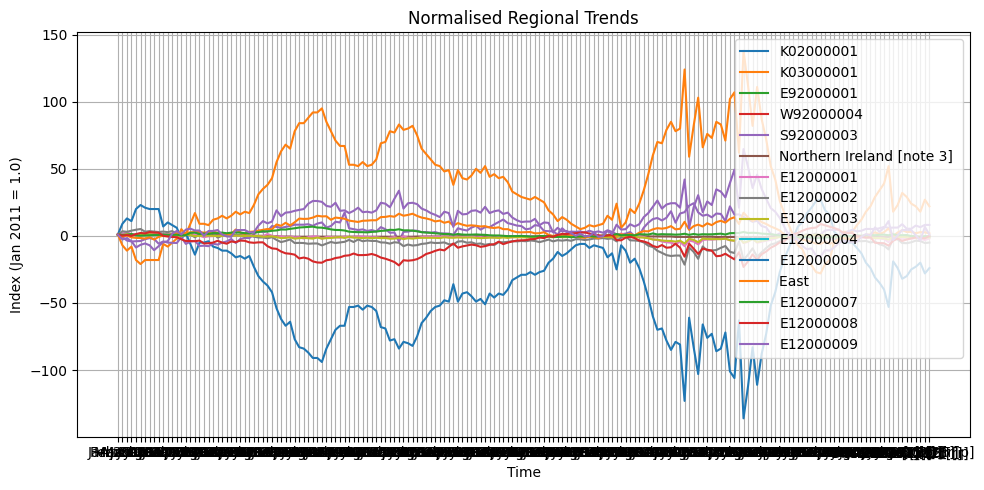

In [6]:
import pandas
import matplotlib.pyplot as plt

df = pandas.read_csv("./data/historical_data.csv")
#df["Time period"] = pandas.to_datetime(df["Time period"])

region_cols = df.columns[1:]

# Normalise each region to its first value
df_norm = df.copy()
df_norm[region_cols] = df_norm[region_cols].div(df_norm[region_cols].iloc[0])

plt.figure(figsize=(10, 5))
for col in region_cols:
    plt.plot(df_norm["Time period"], df_norm[col], label=col)

plt.title("Normalised Regional Trends")
plt.ylabel("Index (Jan 2011 = 1.0)")
plt.xlabel("Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

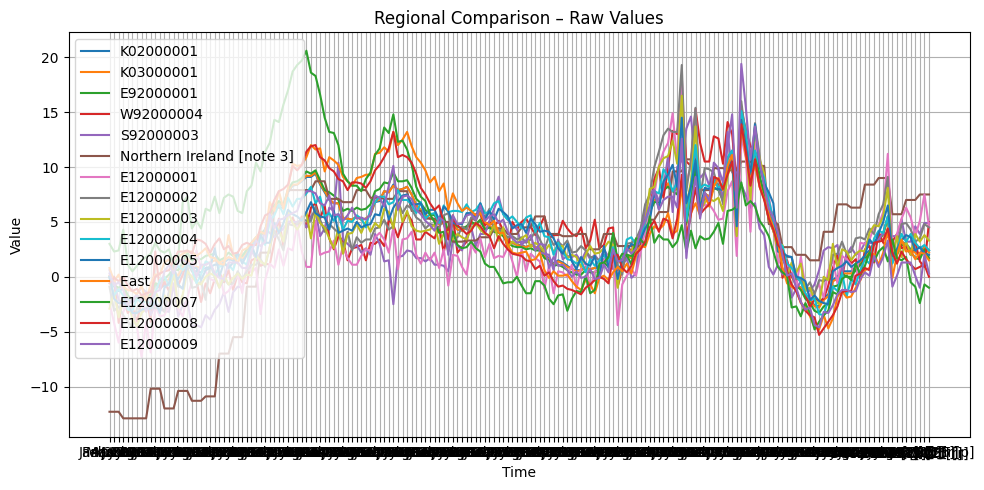

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for col in region_cols:
    plt.plot(df["Time period"], df[col], label=col)

plt.title("Regional Comparison – Raw Values")
plt.ylabel("Value")
plt.xlabel("Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()